In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,  classification_report
)

In [2]:
spy  = pd.read_csv('data/SPY_features.csv',  parse_dates=['date'], index_col='date').sort_index()
tsla = pd.read_csv('data/TSLA_features.csv', parse_dates=['date'], index_col='date').sort_index()

print(f'SPY  : {len(spy):,} rows | {spy.index[0].date()} → {spy.index[-1].date()}')
print(f'TSLA : {len(tsla):,} rows | {tsla.index[0].date()} → {tsla.index[-1].date()}')
print(f'Columns: {list(spy.columns)}')

SPY  : 2,515 rows | 2015-01-02 → 2024-12-30
TSLA : 2,515 rows | 2015-01-02 → 2024-12-30
Columns: ['adj_close', 'close', 'high', 'low', 'open', 'volume', 'daily_return', 'weekly_return', 'ma_7', 'ma_21', 'ma_cross', 'dist_from_ma21', 'daily_range', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_position', 'volatility_7', 'volatility_20', 'volume_change', 'volume_ma20', 'volume_ratio', 'lag_return_1', 'lag_return_3', 'lag_return_5', 'month', 'quarter', 'season_num', 'season', 'is_earnings_week', 'vix', 'is_major_event', 'target_direction', 'target_return']


## Feature Selection

The CSVs contain 35 columns. We select 19 as model features.

**Dropped — raw price columns (not features):**
- `open`, `high`, `low`, `close`, `adj_close`, `volume` — raw OHLCV data, 
  we use derived features from these instead

**Dropped — intermediate calculations:**
- `ma_7`, `ma_21` — used to compute `ma_cross` and `dist_from_ma21`, 
  not useful raw
- `volume_ma20` — used to compute `volume_ratio`, not useful raw

**Dropped — redundant (confirmed by correlation heatmap):**
- `quarter` and `season_num` and `season` — 0.97 correlated with `month`. 
  All three are just different groupings of the same calendar information. 
  `month` is the most granular so it carries everything the other two do.
- `macd` and `macd_signal` — `macd_hist` (macd minus signal) already captures 
  the most actionable signal. It measures if momentum is accelerating or 
  decelerating, more useful than the raw lines individually.


**Targets (not features):**
- `target_direction`, `target_return`

**Final feature count: 19**

In [3]:
TRAIN_WINDOW = 63
TEST_WINDOW = 42


FEATURES = [
    'daily_return', 'weekly_return', 'ma_cross', 'dist_from_ma21', 'daily_range',
    'rsi_14', 'macd_hist', 'bb_position', 'volatility_7', 'volatility_20',
    'volume_change', 'volume_ratio',
    'lag_return_1', 'lag_return_3', 'lag_return_5',
    'month', 'is_earnings_week',
    'vix', 'is_major_event'
]


In [4]:
TARGET_CLS = 'target_direction'
spy_cls  = spy.dropna(subset=FEATURES)
tsla_cls = tsla.dropna(subset=FEATURES)

print(f'SPY  : {len(spy_cls):,} rows')
print(f'TSLA : {len(tsla_cls):,} rows')
print(f'Target balance SPY  — UP: {spy_cls[TARGET_CLS].mean():.1%}  DOWN: {1-spy_cls[TARGET_CLS].mean():.1%}')
print(f'Target balance TSLA — UP: {tsla_cls[TARGET_CLS].mean():.1%}  DOWN: {1-tsla_cls[TARGET_CLS].mean():.1%}')

SPY  : 2,515 rows
TSLA : 2,515 rows
Target balance SPY  — UP: 54.6%  DOWN: 45.4%
Target balance TSLA — UP: 51.8%  DOWN: 48.2%


In [5]:
def walk_forward_splits(df, train_window = TRAIN_WINDOW, test_window = TEST_WINDOW):
    splits = []
    n = len(df)
    start = 0
    
    while start + train_window + test_window <= n:
        train_idx = list(range(start, start + train_window ))
        test_idx = list(range(start + train_window, start + train_window + test_window))
        splits.append((train_idx,test_idx))
        start += test_window
        
    return splits
        

In [6]:
spy_folds  = walk_forward_splits(spy_cls)
tsla_folds = walk_forward_splits(tsla_cls)

print(f'SPY  folds: {len(spy_folds)}')
print(f'TSLA folds: {len(tsla_folds)}')
print(f'\nFirst fold — train: {spy_folds[0][0][0]}→{spy_folds[0][0][-1]}  test: {spy_folds[0][1][0]}→{spy_folds[0][1][-1]}')
print(f'Last  fold — train: {spy_folds[-1][0][0]}→{spy_folds[-1][0][-1]}  test: {spy_folds[-1][1][0]}→{spy_folds[-1][1][-1]}')

SPY  folds: 58
TSLA folds: 58

First fold — train: 0→62  test: 63→104
Last  fold — train: 2394→2456  test: 2457→2498


In [7]:
X_spy = spy_cls[FEATURES].values
Y_spy = spy_cls[TARGET_CLS].values

X_tsla = tsla_cls[FEATURES].values
Y_tsla = tsla_cls[TARGET_CLS].values

print(f'SPY  X: {X_spy.shape}  y: {Y_spy.shape}')
print(f'TSLA X: {X_tsla.shape}  y: {Y_tsla.shape}')

SPY  X: (2515, 19)  y: (2515,)
TSLA X: (2515, 19)  y: (2515,)


In [8]:
def run_logistic(X, y, df, ticker, train_window=TRAIN_WINDOW):
    results = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [],
               'y_true': [], 'y_pred': []}
    
    folds = walk_forward_splits(df, train_window=train_window) 
    print(f'{ticker} — Logistic Regression — {len(folds)} folds')
    
    for fold, (train_idx, test_idx) in enumerate(folds, 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)
        
        model = LogisticRegression(
            class_weight='balanced', max_iter=1000, C=0.1, solver='lbfgs', random_state=42
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        results['accuracy'].append(accuracy_score(y_test, preds))
        results['precision'].append(precision_score(y_test, preds, zero_division=0))
        results['recall'].append(recall_score(y_test, preds, zero_division=0))
        results['f1'].append(f1_score(y_test, preds, zero_division=0))
        results['y_true'].extend(y_test.tolist())
        results['y_pred'].extend(preds.tolist())
        
        if fold % 10 == 0:
            print(f'  Fold {fold}/{len(folds)} done..')
    
    print('  Done ')
    return results

In [9]:
def run_svm(X, y, df, ticker, train_window=TRAIN_WINDOW):
    results = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [],
               'y_true': [], 'y_pred': []}

    folds = walk_forward_splits(df, train_window=train_window) 
    print(f'{ticker} — SVM — {len(folds)} folds')
    
    for fold, (train_idx, test_idx) in enumerate(folds, 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)
        
        model = SVC(
            class_weight='balanced', kernel='rbf', C=1.0, random_state=42
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        results['accuracy'].append(accuracy_score(y_test, preds))
        results['precision'].append(precision_score(y_test, preds, zero_division=0))
        results['recall'].append(recall_score(y_test, preds, zero_division=0))
        results['f1'].append(f1_score(y_test, preds, zero_division=0))
        results['y_true'].extend(y_test.tolist())
        results['y_pred'].extend(preds.tolist())
        
        if fold % 10 == 0:
            print(f'  Fold {fold}/{len(folds)} done..')
    
    print('  Done ')
    return results

In [10]:
def run_random_forest(X, y, df, ticker, train_window=TRAIN_WINDOW):
    results = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [],
               'y_true': [], 'y_pred': [], 'feature_importance': []}
    
    folds = walk_forward_splits(df, train_window=train_window) 
    print(f'{ticker} — Random Forest — {len(folds)} folds')
    
    for fold, (train_idx, test_idx) in enumerate(folds, 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)
        
        model = RandomForestClassifier(
            class_weight='balanced', n_estimators=200, max_depth=6,
            min_samples_leaf=10, random_state=42, n_jobs=-1
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        results['accuracy'].append(accuracy_score(y_test, preds))
        results['precision'].append(precision_score(y_test, preds, zero_division=0))
        results['recall'].append(recall_score(y_test, preds, zero_division=0))
        results['f1'].append(f1_score(y_test, preds, zero_division=0))
        results['y_true'].extend(y_test.tolist())
        results['y_pred'].extend(preds.tolist())
        results['feature_importance'].append(model.feature_importances_)
        
        if fold % 10 == 0:
            print(f'  Fold {fold}/{len(folds)} done..')
    
    print('  Done ')
    return results

In [11]:
def print_cls_results(results, ticker, model_name):
    print(f'=== {ticker} — {model_name} ===')
    print(f'  Accuracy  : {np.mean(results["accuracy"]):.4f} ± {np.std(results["accuracy"]):.4f}')
    print(f'  Precision : {np.mean(results["precision"]):.4f} ± {np.std(results["precision"]):.4f}')
    print(f'  Recall    : {np.mean(results["recall"]):.4f} ± {np.std(results["recall"]):.4f}')
    print(f'  F1        : {np.mean(results["f1"]):.4f} ± {np.std(results["f1"]):.4f}')
    print()

In [12]:
# SPY — 189 day train window
lr_spy  = run_logistic(X_spy,  Y_spy,  spy_cls,  'SPY',  train_window=189)
svm_spy = run_svm(X_spy,  Y_spy,  spy_cls,  'SPY',  train_window=189)
rf_spy  = run_random_forest(X_spy,  Y_spy,  spy_cls,  'SPY',  train_window=189)

# TSLA — 59 day train window
lr_tsla  = run_logistic(X_tsla,  Y_tsla,  tsla_cls,  'TSLA',  train_window=59)
svm_tsla = run_svm(X_tsla,  Y_tsla,  tsla_cls,  'TSLA',  train_window=59)
rf_tsla  = run_random_forest(X_tsla,  Y_tsla,  tsla_cls,  'TSLA',  train_window=59)

SPY — Logistic Regression — 55 folds
  Fold 10/55 done..
  Fold 20/55 done..
  Fold 30/55 done..
  Fold 40/55 done..
  Fold 50/55 done..
  Done 
SPY — SVM — 55 folds
  Fold 10/55 done..
  Fold 20/55 done..
  Fold 30/55 done..
  Fold 40/55 done..
  Fold 50/55 done..
  Done 
SPY — Random Forest — 55 folds
  Fold 10/55 done..
  Fold 20/55 done..
  Fold 30/55 done..
  Fold 40/55 done..
  Fold 50/55 done..
  Done 
TSLA — Logistic Regression — 58 folds
  Fold 10/58 done..
  Fold 20/58 done..
  Fold 30/58 done..
  Fold 40/58 done..
  Fold 50/58 done..
  Done 
TSLA — SVM — 58 folds
  Fold 10/58 done..
  Fold 20/58 done..
  Fold 30/58 done..
  Fold 40/58 done..
  Fold 50/58 done..
  Done 
TSLA — Random Forest — 58 folds
  Fold 10/58 done..
  Fold 20/58 done..
  Fold 30/58 done..
  Fold 40/58 done..
  Fold 50/58 done..
  Done 


In [13]:
print_cls_results(lr_spy,  'SPY',  'Logistic Regression')
print_cls_results(svm_spy, 'SPY',  'SVM')
print_cls_results(rf_spy,  'SPY',  'Random Forest')

print('---')

print_cls_results(lr_tsla,  'TSLA', 'Logistic Regression')
print_cls_results(svm_tsla, 'TSLA', 'SVM')
print_cls_results(rf_tsla,  'TSLA', 'Random Forest')

=== SPY — Logistic Regression ===
  Accuracy  : 0.4922 ± 0.0871
  Precision : 0.5332 ± 0.1653
  Recall    : 0.4784 ± 0.2525
  F1        : 0.4709 ± 0.1818

=== SPY — SVM ===
  Accuracy  : 0.5061 ± 0.0771
  Precision : 0.5455 ± 0.1402
  Recall    : 0.5392 ± 0.2546
  F1        : 0.5119 ± 0.1656

=== SPY — Random Forest ===
  Accuracy  : 0.5177 ± 0.0780
  Precision : 0.5662 ± 0.1287
  Recall    : 0.5682 ± 0.2229
  F1        : 0.5407 ± 0.1364

---
=== TSLA — Logistic Regression ===
  Accuracy  : 0.4979 ± 0.0745
  Precision : 0.4975 ± 0.1549
  Recall    : 0.4909 ± 0.3000
  F1        : 0.4482 ± 0.2020

=== TSLA — SVM ===
  Accuracy  : 0.4856 ± 0.0744
  Precision : 0.4898 ± 0.1507
  Recall    : 0.4737 ± 0.2875
  F1        : 0.4362 ± 0.2033

=== TSLA — Random Forest ===
  Accuracy  : 0.5029 ± 0.0705
  Precision : 0.5373 ± 0.1368
  Recall    : 0.5222 ± 0.2299
  F1        : 0.4954 ± 0.1380



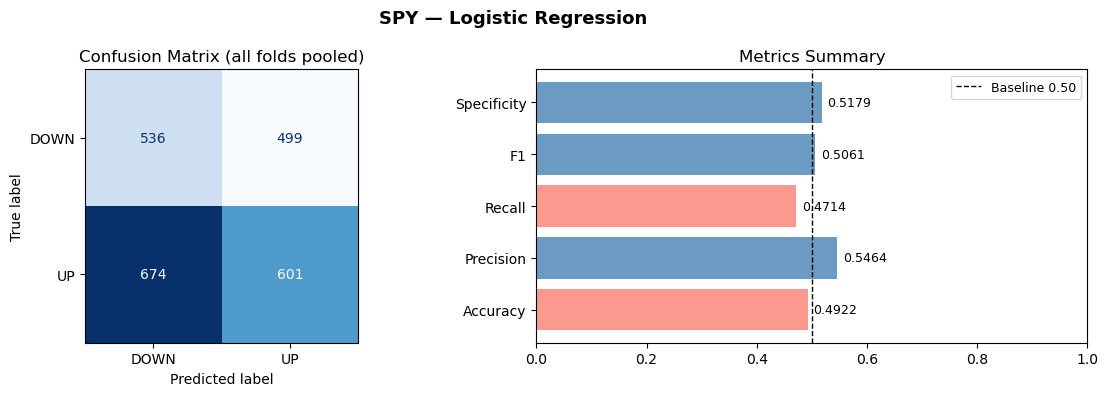


SPY — Logistic Regression
  TP=601  TN=536  FP=499  FN=674
  Accuracy    : 0.4922
  Precision   : 0.5464  (of predicted UP, how many were actually UP)
  Recall      : 0.4714  (of actual UP days, how many did we catch)
  F1          : 0.5061
  Specificity : 0.5179  (of actual DOWN days, how many did we catch)

              precision    recall  f1-score   support

           0       0.44      0.52      0.48      1035
           1       0.55      0.47      0.51      1275

    accuracy                           0.49      2310
   macro avg       0.49      0.49      0.49      2310
weighted avg       0.50      0.49      0.49      2310

--------------------------------------------------


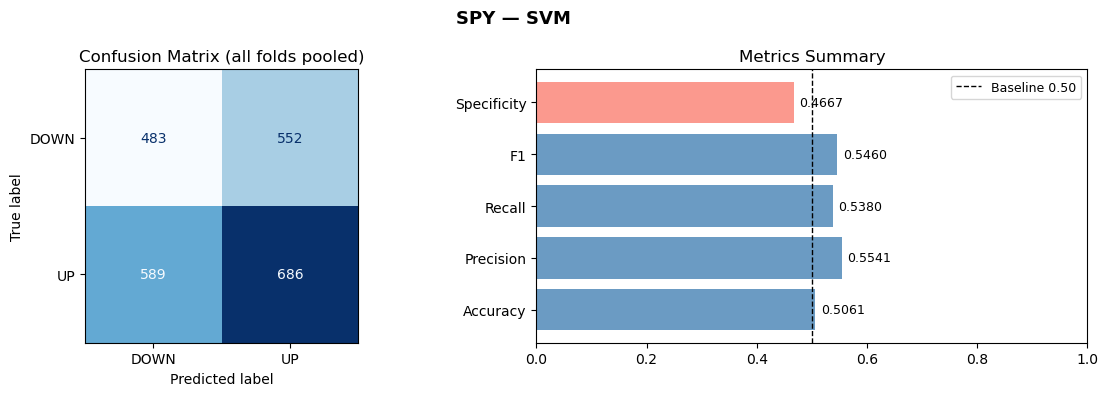


SPY — SVM
  TP=686  TN=483  FP=552  FN=589
  Accuracy    : 0.5061
  Precision   : 0.5541  (of predicted UP, how many were actually UP)
  Recall      : 0.5380  (of actual UP days, how many did we catch)
  F1          : 0.5460
  Specificity : 0.4667  (of actual DOWN days, how many did we catch)

              precision    recall  f1-score   support

           0       0.45      0.47      0.46      1035
           1       0.55      0.54      0.55      1275

    accuracy                           0.51      2310
   macro avg       0.50      0.50      0.50      2310
weighted avg       0.51      0.51      0.51      2310

--------------------------------------------------


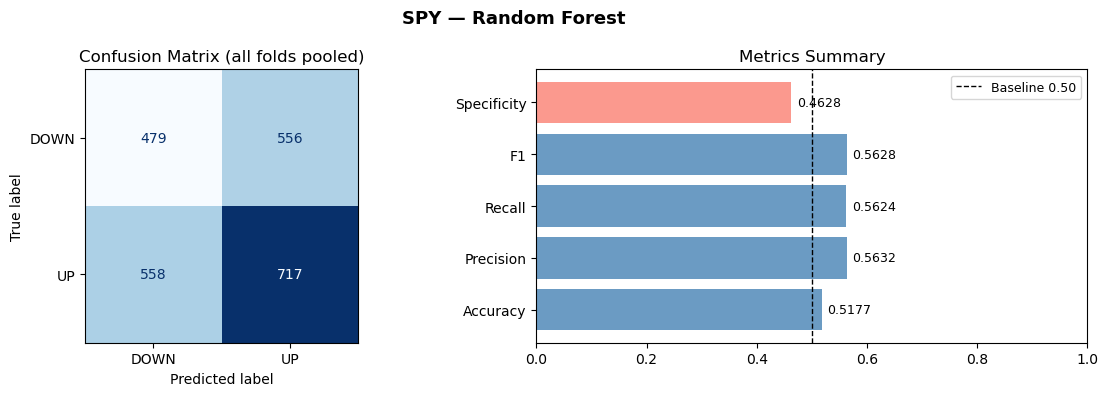


SPY — Random Forest
  TP=717  TN=479  FP=556  FN=558
  Accuracy    : 0.5177
  Precision   : 0.5632  (of predicted UP, how many were actually UP)
  Recall      : 0.5624  (of actual UP days, how many did we catch)
  F1          : 0.5628
  Specificity : 0.4628  (of actual DOWN days, how many did we catch)

              precision    recall  f1-score   support

           0       0.46      0.46      0.46      1035
           1       0.56      0.56      0.56      1275

    accuracy                           0.52      2310
   macro avg       0.51      0.51      0.51      2310
weighted avg       0.52      0.52      0.52      2310

--------------------------------------------------


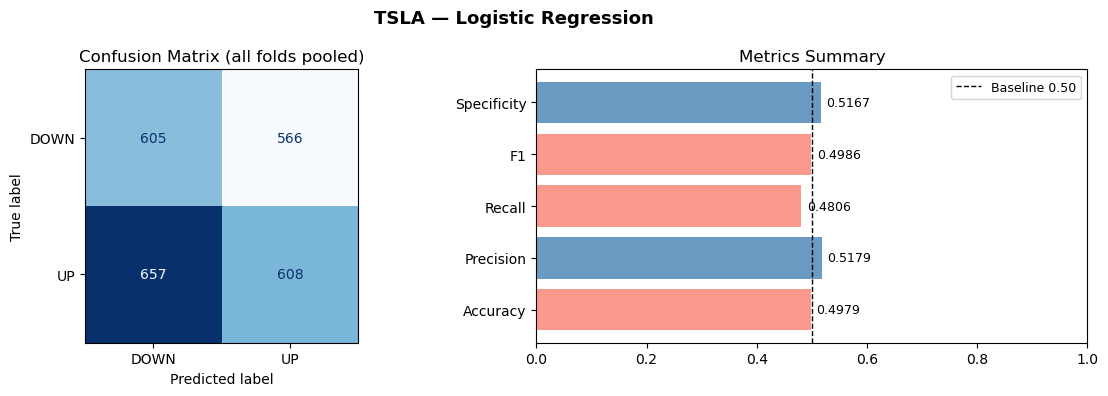


TSLA — Logistic Regression
  TP=608  TN=605  FP=566  FN=657
  Accuracy    : 0.4979
  Precision   : 0.5179  (of predicted UP, how many were actually UP)
  Recall      : 0.4806  (of actual UP days, how many did we catch)
  F1          : 0.4986
  Specificity : 0.5167  (of actual DOWN days, how many did we catch)

              precision    recall  f1-score   support

           0       0.48      0.52      0.50      1171
           1       0.52      0.48      0.50      1265

    accuracy                           0.50      2436
   macro avg       0.50      0.50      0.50      2436
weighted avg       0.50      0.50      0.50      2436

--------------------------------------------------


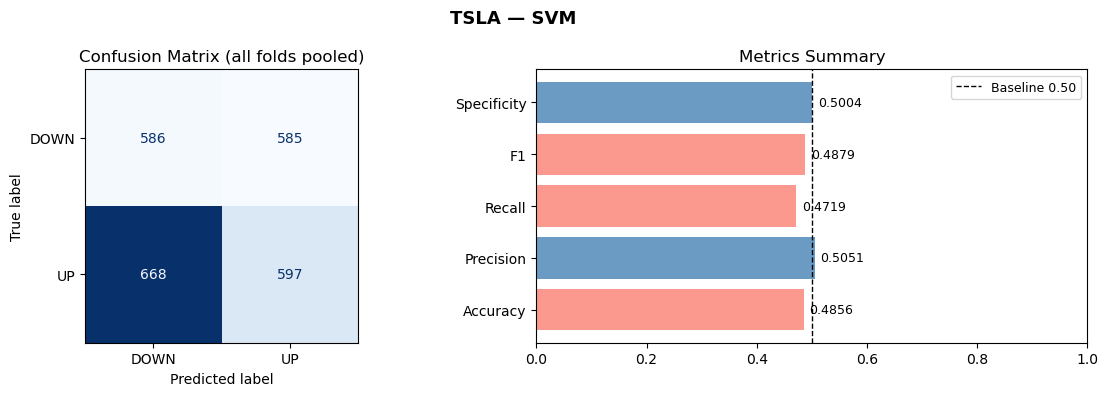


TSLA — SVM
  TP=597  TN=586  FP=585  FN=668
  Accuracy    : 0.4856
  Precision   : 0.5051  (of predicted UP, how many were actually UP)
  Recall      : 0.4719  (of actual UP days, how many did we catch)
  F1          : 0.4879
  Specificity : 0.5004  (of actual DOWN days, how many did we catch)

              precision    recall  f1-score   support

           0       0.47      0.50      0.48      1171
           1       0.51      0.47      0.49      1265

    accuracy                           0.49      2436
   macro avg       0.49      0.49      0.49      2436
weighted avg       0.49      0.49      0.49      2436

--------------------------------------------------


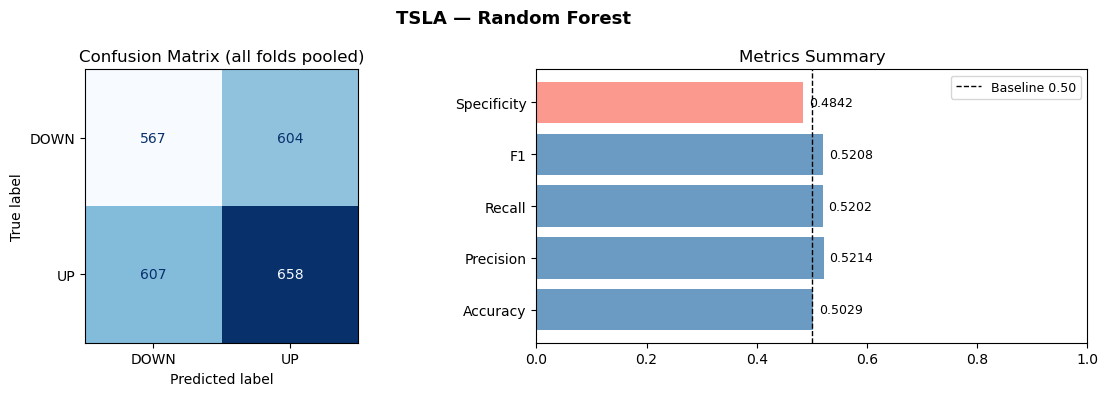


TSLA — Random Forest
  TP=658  TN=567  FP=604  FN=607
  Accuracy    : 0.5029
  Precision   : 0.5214  (of predicted UP, how many were actually UP)
  Recall      : 0.5202  (of actual UP days, how many did we catch)
  F1          : 0.5208
  Specificity : 0.4842  (of actual DOWN days, how many did we catch)

              precision    recall  f1-score   support

           0       0.48      0.48      0.48      1171
           1       0.52      0.52      0.52      1265

    accuracy                           0.50      2436
   macro avg       0.50      0.50      0.50      2436
weighted avg       0.50      0.50      0.50      2436

--------------------------------------------------


In [16]:
def plot_confusion_matrix_full(results, ticker, model_name):
    y_true = results['y_true']
    y_pred = results['y_pred']
    
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract TP, TN, FP, FN
    TN, FP, FN, TP = cm.ravel()
    
    # Metrics
    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{ticker} — {model_name}', fontsize=13, fontweight='bold')
    
    # Confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['DOWN', 'UP'])
    disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title('Confusion Matrix (all folds pooled)')
    
    # Metrics bar chart
    metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1', 'Specificity']
    metric_values = [acc, precision, recall, f1, specificity]
    colors = ['steelblue' if v >= 0.5 else 'salmon' for v in metric_values]
    
    axes[1].barh(metric_names, metric_values, color=colors, alpha=0.8)
    axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=1, label='Baseline 0.50')
    axes[1].set_xlim(0, 1)
    axes[1].set_title('Metrics Summary')
    axes[1].legend(fontsize=9)
    for i, v in enumerate(metric_values):
        axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed report
    print(f'\n{ticker} — {model_name}')
    print(f'  TP={TP}  TN={TN}  FP={FP}  FN={FN}')
    print(f'  Accuracy    : {acc:.4f}')
    print(f'  Precision   : {precision:.4f}  (of predicted UP, how many were actually UP)')
    print(f'  Recall      : {recall:.4f}  (of actual UP days, how many did we catch)')
    print(f'  F1          : {f1:.4f}')
    print(f'  Specificity : {specificity:.4f}  (of actual DOWN days, how many did we catch)')
    print()
    print(classification_report(y_true, y_pred,  zero_division=0))
    print('-' * 50)


# ── SPY ───────────────────────────────────────────────
plot_confusion_matrix_full(lr_spy,  'SPY', 'Logistic Regression')
plot_confusion_matrix_full(svm_spy, 'SPY', 'SVM')
plot_confusion_matrix_full(rf_spy,  'SPY', 'Random Forest')

# ── TSLA ──────────────────────────────────────────────
plot_confusion_matrix_full(lr_tsla,  'TSLA', 'Logistic Regression')
plot_confusion_matrix_full(svm_tsla, 'TSLA', 'SVM')
plot_confusion_matrix_full(rf_tsla,  'TSLA', 'Random Forest')